<a href="https://colab.research.google.com/github/AndresHD1/mineria_de_datos/blob/main/Entrega_mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link de descarga del dataset: "
https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset"

Integrantes: Mateo Carrasco y Adolfo Cartes

In [ ]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Se define el dataset

df = pd.read_csv('/content/Video_Games_Sales_as_at_22_Dec_2016.csv')

In [ ]:
#Vemos las primeras 5 filas

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(16719, 16)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Name,object
Platform,object
Year_of_Release,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
tipos = df.columns.to_series().groupby(df.dtypes).groups
# Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) # cantidad de columnas con datos categóricos.

6

In [ ]:
 # Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


10

In [ ]:
#Se tratan los nulos para las variables numericas

for columna in cnum:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)


In [ ]:
#Se tratan los nulos para las variables categoricas

for columna in ctext:
    df[columna] = df[columna].fillna("Desconocido")

In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,0
Platform,0
Year_of_Release,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

MAPEO DE DATOS

*   Name: Categórico Nominal
*   Platform: Categórico Nominal
*   Year_of_Release: Numérico Discreto
*   Genre: Categórico Nominal
*   Publisher: Categórico Nominal
*   NA_Sales: Numérico Continuo
*   EU_Sales: Numérico Continuo
*   JP_Sales: Numérico Continuo
*   Other_Sales: Numérico Continuo
*   Global_Sales: Numérico Continuo
*   Critic_Score: Numérico Discreto
*   Critic_Count: Numérico Discreto
*   User_Score: Numérico Continuo
*   User_Count: Numérico Discreto
*   Developer: Categórico Nominal
*   Rating: Categórico Nominal




In [ ]:
cant_cat_name_plat_df = df['Name'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de nombe
print(cant_cat_name_plat_df)

print(f"cantidad de nombes: {cant_cat_name_plat_df.count()}")

Name
Need for Speed: Most Wanted      12
Ratatouille                       9
LEGO Marvel Super Heroes          9
Madden NFL 07                     9
FIFA 14                           9
                                 ..
Outdoors Unleashed: Africa 3D     1
Real Rode                         1
PGA European Tour                 1
Duck Hunt                         1
New Super Mario Bros. Wii         1
Name: count, Length: 11563, dtype: int64
cantidad de nombes: 11563


In [ ]:
cant_cat_col_plat_df = df['Platform'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de gategorias
print(cant_cat_col_plat_df)

print(f"cantidad de plataformas: {cant_cat_col_plat_df.count()}")

Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      432
PS4      393
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
cantidad de plataformas: 31


In [ ]:
cant_cat_genre_plat_df = df['Genre'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Genero
print(cant_cat_genre_plat_df)

print(f"cantidad de generos: {cant_cat_genre_plat_df.count()}")

Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Desconocido        2
Name: count, dtype: int64
cantidad de generos: 13


In [ ]:
cant_cat_publi_plat_df = df['Publisher'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Publicadores
print(cant_cat_publi_plat_df)

print(f"cantidad de publicadores: {cant_cat_publi_plat_df.count()}")

Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
                                ... 
Commseed                           1
UIG Entertainment                  1
Mirai Shounen                      1
Imageworks                         1
Karin Entertainment                1
Name: count, Length: 583, dtype: int64
cantidad de publicadores: 583


In [ ]:
cant_cat_dev_plat_df = df['Developer'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Developers
print(cant_cat_dev_plat_df)

print(f"cantidad de desarolladores: {cant_cat_dev_plat_df.count()}")

Developer
Desconocido                            6623
Ubisoft                                 204
EA Sports                               172
EA Canada                               167
Konami                                  162
                                       ... 
Camouflaj, LLC                            1
Compulsion Games                          1
Inferno Games                             1
Papyrus                                   1
Bigben Interactive, Red Wagon Games       1
Name: count, Length: 1697, dtype: int64
cantidad de desarolladores: 1697


In [ ]:
cant_cat_rating_plat_df = df['Rating'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Rating
print(cant_cat_rating_plat_df)

print(f"cantidad de Ratings: {cant_cat_rating_plat_df.count()}")

Rating
Desconocido    6769
E              3991
T              2961
M              1563
E10+           1420
EC                8
K-A               3
RP                3
AO                1
Name: count, dtype: int64
cantidad de Ratings: 9


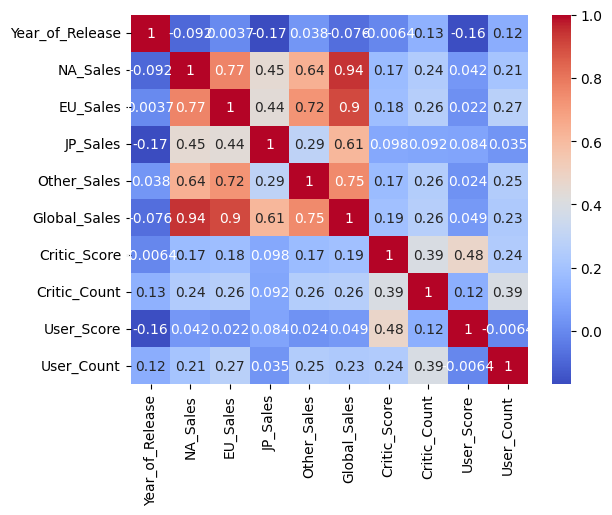

In [ ]:
corr = df.select_dtypes(include='number').corr()
#corr_ejem2 = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.00000,16719.000000
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


In [ ]:
# 1. Definimos todas las columnas que deberían ser numéricas según nuestro mapeo anterior
cols_numericas = [
    'Year_of_Release', 'NA_Sales', 'EU_Sales', 'JP_Sales',
    'Other_Sales', 'Global_Sales', 'Critic_Score',
    'Critic_Count', 'User_Score', 'User_Count'
]

# 2. Conversión masiva a numérico
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# 3. Ajuste de tipos enteros
cols_enteras = ['Year_of_Release', 'Critic_Score', 'Critic_Count', 'User_Count']

for col in cols_enteras:
    if col in df.columns:
        df[col] = df[col].astype('Int64')

In [ ]:
df.describe() # Vemos como quedo luego de convertir todos los datos numéricos y ajustar los enteros

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16719.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.0,16719.0,16719.00000,16719.0
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.0,3.0,0.00000,4.0
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,71.0,21.0,7.50000,24.0
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.0,21.0,7.50000,24.0
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,71.0,21.0,7.50000,24.0
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.0,113.0,9.70000,10665.0


In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.2 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
cols_para_ohe = ['Platform', 'Genre', 'Rating']
cols_para_binary = ['Publisher', 'Developer']

# --- PROCESO ONE-HOT ENCODING ---
ohe = OneHotEncoder(sparse_output=False)
ohe_encoded = ohe.fit_transform(df[cols_para_ohe])

# Creamos el DataFrame de OHE con nombres claros
ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(cols_para_ohe),
    index=df.index
)

# --- PROCESO BINARY ENCODING ---
be = ce.BinaryEncoder(cols=cols_para_binary)
df_binary = be.fit_transform(df[cols_para_binary])

# --- CONCATENACIÓN FINAL ---
# Eliminamos las columnas originales y la de 'Name'
df_final = pd.concat([
    df.drop(columns=cols_para_ohe + cols_para_binary + ['Name']),
    ohe_df,
    df_binary
], axis=1)
# Ver resultados
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")
print(df_final.head())

Total de columnas tras el mapeo: 84
   Year_of_Release  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
0             2006     41.36     28.96      3.77         8.45         82.53   
1             1985     29.08      3.58      6.81         0.77         40.24   
2             2008     15.68     12.76      3.79         3.29         35.52   
3             2009     15.61     10.93      3.28         2.95         32.77   
4             1996     11.27      8.89     10.22         1.00         31.37   

   Critic_Score  Critic_Count  User_Score  User_Count  ...  Developer_1  \
0            76            51         8.0         322  ...            0   
1            71            21         7.5          24  ...            0   
2            82            73         8.3         709  ...            0   
3            80            73         8.0         192  ...            0   
4            71            21         7.5          24  ...            0   

   Developer_2  Developer_3  Developer

In [ ]:
df_final.head(100)

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Developer_1,Developer_2,Developer_3,Developer_4,Developer_5,Developer_6,Developer_7,Developer_8,Developer_9,Developer_10
0,2006,41.36,28.96,3.77,8.45,82.53,76,51,8.0,322,...,0,0,0,0,0,0,0,0,0,1
1,1985,29.08,3.58,6.81,0.77,40.24,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
2,2008,15.68,12.76,3.79,3.29,35.52,82,73,8.3,709,...,0,0,0,0,0,0,0,0,0,1
3,2009,15.61,10.93,3.28,2.95,32.77,80,73,8.0,192,...,0,0,0,0,0,0,0,0,0,1
4,1996,11.27,8.89,10.22,1.00,31.37,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1997,3.78,2.17,1.31,0.31,7.58,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
96,2014,3.27,1.37,2.43,0.48,7.55,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
97,2010,3.56,2.35,0.98,0.62,7.51,97,87,9.1,1854,...,0,0,0,0,0,1,1,1,0,1
98,1988,5.39,1.18,0.70,0.19,7.46,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
df_final.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Developer_1,Developer_2,Developer_3,Developer_4,Developer_5,Developer_6,Developer_7,Developer_8,Developer_9,Developer_10
count,16719.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.0,16719.0,16719.00000,16719.0,...,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856,...,0.139602,0.192117,0.244153,0.265805,0.313416,0.313535,0.275256,0.322926,0.704827,0.307494
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835,...,0.346584,0.393976,0.429597,0.441774,0.463896,0.463944,0.446656,0.467609,0.456134,0.461470
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.0,3.0,0.00000,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.0,113.0,9.70000,10665.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
